### IDMB 리뷰 데이터를 이용한 정수 인코딩과 패딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

from tqdm import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

In [2]:
file_id = "1tqZpPvvyluyu7VVvk99tKpJd4cIkS4yi"
gdown.download("https://drive.google.com/uc?id=" + file_id, "IMDB_Dataset.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1tqZpPvvyluyu7VVvk99tKpJd4cIkS4yi
To: c:\NLP\notebooks\IMDB_Dataset.csv
100%|██████████| 66.2M/66.2M [00:03<00:00, 21.4MB/s]


'IMDB_Dataset.csv'

In [3]:
df = pd.read_csv("IMDB_Dataset.csv")

df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
print('결측값 여부 :',df.isnull().values.any())

결측값 여부 : False


<Axes: xlabel='sentiment'>

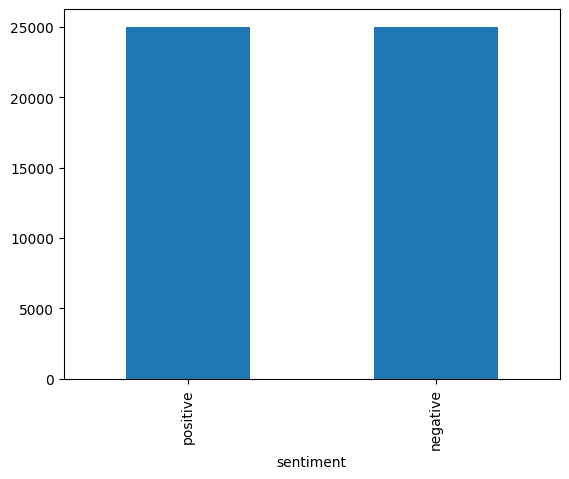

In [6]:
df['sentiment'].value_counts().plot(kind='bar')

In [7]:
print('레이블 개수')
print(df.groupby('sentiment').size().reset_index(name='count'))

레이블 개수
  sentiment  count
0  negative  25000
1  positive  25000


In [8]:
df['sentiment'] = df['sentiment'].map({'positive' : 1, 'negative' : 0})

In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [10]:
X_data = df['review']
y_data = df['sentiment']
print('영화 리뷰의 개수: {}'.format(len(X_data)))
print('레이블의 개수: {}'.format(len(y_data)))

영화 리뷰의 개수: 50000
레이블의 개수: 50000


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.5, random_state=0, stratify=y_data)

In [12]:
print('--------훈련 데이터의 비율-----------')
print(f'긍정 리뷰 = {round(y_train.value_counts()[0] / len(y_train) * 100, 3)}%')
print(f'부정 리뷰 = {round(y_train.value_counts()[1] / len(y_train) * 100, 3)}%')
print('--------테스트 데이터의 비율-----------')
print(f'긍정 리뷰 = {round(y_test.value_counts()[0] / len(y_test) * 100, 3)}%')
print(f'부정 리뷰 = {round(y_test.value_counts()[1] / len(y_test) * 100, 3)}%')

--------훈련 데이터의 비율-----------
긍정 리뷰 = 50.0%
부정 리뷰 = 50.0%
--------테스트 데이터의 비율-----------
긍정 리뷰 = 50.0%
부정 리뷰 = 50.0%


In [15]:
def tokenize(sentences):
  tokenized_sentences = []
  for sent in tqdm(sentences):
    tokenized_sent = word_tokenize(sent)
    tokenized_sent = [word.lower() for word in tokenized_sent]
    tokenized_sentences.append(tokenized_sent)
  return tokenized_sentences

In [16]:
tokenized_X_train = tokenize(X_train)
tokenized_X_test = tokenize(X_test)

100%|██████████| 25000/25000 [00:29<00:00, 843.38it/s]


In [17]:
word_list = []
for sent in tokenized_X_train:
    for word in sent:
        word_list.append(word)

word_counts = Counter(word_list)
print('총 단어수 : ', len(word_counts))

총 단어수 :  112944


In [19]:
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
print('등장 빈도수 상위 10개 단어')
print(vocab[:10])

등장 빈도수 상위 10개 단어
['the', ',', '.', 'and', 'a', 'of', 'to', 'is', '/', '>']


In [ ]:
threshold = 3
total_cnt = len(word_counts)    # 단어의 수
rare_cnt = 0                    # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0                  # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0                   # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s' % (threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt) * 100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq) * 100)

단어 집합(vocabulary)의 크기 : 112944
등장 빈도가 2번 이하인 희귀 단어의 수: 69668
단어 집합에서 희귀 단어의 비율: 61.683666241677294
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.1945684263086243


In [20]:
# 전체 단어 개수 중 빈도수 1이하인 단어는 제거
vocab_size = total_cnt - rare_cnt
vocab = vocab[:vocab_size]
print('단어 집합의 크기 :', len(vocab))

단어 집합의 크기 : 43276


In [21]:
word_to_index = {}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

In [22]:
for index, word in enumerate(vocab) :
  word_to_index[word] = index + 2

In [23]:
print(word_to_index)

{'<PAD>': 0, '<UNK>': 1, 'the': 2, ',': 3, '.': 4, 'and': 5, 'a': 6, 'of': 7, 'to': 8, 'is': 9, '/': 10, '>': 11, '<': 12, 'br': 13, 'it': 14, 'in': 15, 'i': 16, 'this': 17, 'that': 18, "'s": 19, 'was': 20, 'as': 21, 'with': 22, 'for': 23, 'movie': 24, 'but': 25, 'film': 26, ')': 27, '(': 28, 'you': 29, 'on': 30, "n't": 31, "''": 32, '``': 33, 'not': 34, 'are': 35, 'he': 36, 'his': 37, 'have': 38, 'be': 39, 'one': 40, '!': 41, 'at': 42, 'they': 43, 'all': 44, 'by': 45, 'an': 46, 'who': 47, 'from': 48, 'so': 49, 'like': 50, 'there': 51, 'or': 52, 'just': 53, 'do': 54, 'her': 55, 'if': 56, 'about': 57, 'has': 58, 'out': 59, '?': 60, 'what': 61, 'some': 62, 'when': 63, 'good': 64, 'more': 65, 'very': 66, 'she': 67, 'would': 68, 'up': 69, 'my': 70, 'even': 71, 'no': 72, 'can': 73, 'time': 74, 'which': 75, 'only': 76, 'really': 77, 'their': 78, 'see': 79, 'had': 80, 'story': 81, 'were': 82, 'did': 83, 'we': 84, 'me': 85, 'does': 86, '...': 87, "'": 88, 'much': 89, 'well': 90, '-': 91, ':': 

In [24]:
def texts_to_sequences(tokenized_X_data, word_to_index):
  encoded_X_data = []
  for sent in tokenized_X_data:
    index_sequences = []
    for word in sent:
      try:
          index_sequences.append(word_to_index[word])
      except KeyError:
          index_sequences.append(word_to_index['<UNK>'])
    encoded_X_data.append(index_sequences)
  return encoded_X_data

In [25]:
encoded_X_train = texts_to_sequences(tokenized_X_train, word_to_index)
encoded_X_test = texts_to_sequences(tokenized_X_test, word_to_index)

In [26]:
print(encoded_X_train[0])

[139, 9, 117, 353, 8, 459, 30, 129, 635, 7, 360, 1934, 50, 17, 3, 898, 29, 192, 6, 5485, 1, 4041, 346, 188, 261, 22, 72, 307, 7, 605, 5, 176, 143, 8, 54, 4, 772, 119, 3, 351, 132, 28, 4786, 1386, 27, 3, 838, 81, 3, 617, 1057, 3, 5, 104, 681, 8, 17, 123, 2958, 1, 40, 1994, 57, 2, 2346, 950, 632, 4]


In [27]:
index_to_word = {}
for key, value in word_to_index.items():
    index_to_word[value] = key

In [28]:
print(word_to_index)
print(index_to_word)

{'<PAD>': 0, '<UNK>': 1, 'the': 2, ',': 3, '.': 4, 'and': 5, 'a': 6, 'of': 7, 'to': 8, 'is': 9, '/': 10, '>': 11, '<': 12, 'br': 13, 'it': 14, 'in': 15, 'i': 16, 'this': 17, 'that': 18, "'s": 19, 'was': 20, 'as': 21, 'with': 22, 'for': 23, 'movie': 24, 'but': 25, 'film': 26, ')': 27, '(': 28, 'you': 29, 'on': 30, "n't": 31, "''": 32, '``': 33, 'not': 34, 'are': 35, 'he': 36, 'his': 37, 'have': 38, 'be': 39, 'one': 40, '!': 41, 'at': 42, 'they': 43, 'all': 44, 'by': 45, 'an': 46, 'who': 47, 'from': 48, 'so': 49, 'like': 50, 'there': 51, 'or': 52, 'just': 53, 'do': 54, 'her': 55, 'if': 56, 'about': 57, 'has': 58, 'out': 59, '?': 60, 'what': 61, 'some': 62, 'when': 63, 'good': 64, 'more': 65, 'very': 66, 'she': 67, 'would': 68, 'up': 69, 'my': 70, 'even': 71, 'no': 72, 'can': 73, 'time': 74, 'which': 75, 'only': 76, 'really': 77, 'their': 78, 'see': 79, 'had': 80, 'story': 81, 'were': 82, 'did': 83, 'we': 84, 'me': 85, 'does': 86, '...': 87, "'": 88, 'much': 89, 'well': 90, '-': 91, ':': 

In [29]:
decoded_sample = [index_to_word[word] for word in encoded_X_train[0]]
print('기존의 첫번째 샘플 :', tokenized_X_train[0])
print('복원된 첫번째 샘플 :', decoded_sample)

기존의 첫번째 샘플 : ['life', 'is', 'too', 'short', 'to', 'waste', 'on', 'two', 'hours', 'of', 'hollywood', 'nonsense', 'like', 'this', ',', 'unless', 'you', "'re", 'a', 'clueless', 'naiive', '16', 'year', 'old', 'girl', 'with', 'no', 'sense', 'of', 'reality', 'and', 'nothing', 'better', 'to', 'do', '.', 'dull', 'characters', ',', 'poor', 'acting', '(', 'artificial', 'emotion', ')', ',', 'weak', 'story', ',', 'slow', 'pace', ',', 'and', 'most', 'important', 'to', 'this', 'films', 'flawed', 'existence-no', 'one', 'cares', 'about', 'the', 'overly', 'dramatic', 'relationship', '.']
복원된 첫번째 샘플 : ['life', 'is', 'too', 'short', 'to', 'waste', 'on', 'two', 'hours', 'of', 'hollywood', 'nonsense', 'like', 'this', ',', 'unless', 'you', "'re", 'a', 'clueless', '<UNK>', '16', 'year', 'old', 'girl', 'with', 'no', 'sense', 'of', 'reality', 'and', 'nothing', 'better', 'to', 'do', '.', 'dull', 'characters', ',', 'poor', 'acting', '(', 'artificial', 'emotion', ')', ',', 'weak', 'story', ',', 'slow', 'pace', ',

리뷰의 최대 길이 : 2818
리뷰의 평균 길이 : 279.09996


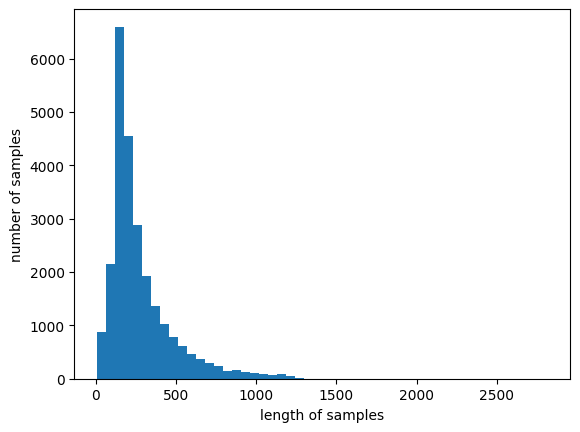

In [30]:
print('리뷰의 최대 길이 :',max(len(review) for review in encoded_X_train))
print('리뷰의 평균 길이 :',sum(map(len, encoded_X_train)) / len(encoded_X_train))
plt.hist([len(review) for review in encoded_X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [31]:
def below_threshold_len(max_len, nested_list):
  count = 0
  for sentence in nested_list:
    if(len(sentence) <= max_len):
        count = count + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s' % (max_len, (count / len(nested_list))*100))

In [32]:
max_len = 500
below_threshold_len(max_len, encoded_X_train)

전체 샘플 중 길이가 500 이하인 샘플의 비율: 87.836


In [36]:
def pad_sequences(sentences, max_len):
  features = np.zeros((len(sentences), max_len), dtype=int)
  for index, sentence in enumerate(sentences):
    if len(sentence) != 0:
      features[index, :len(sentence)] = np.array(sentence)[:max_len]
  return features

In [37]:
padded_X_train = pad_sequences(encoded_X_train, max_len=max_len)
padded_X_test = pad_sequences(encoded_X_test, max_len=max_len)

In [38]:
print('훈련 데이터의 크기 :', padded_X_train.shape)
print('테스트 데이터의 크기 :', padded_X_test.shape)

훈련 데이터의 크기 : (25000, 500)
테스트 데이터의 크기 : (25000, 500)


In [39]:
print(padded_X_train[0])

[ 139    9  117  353    8  459   30  129  635    7  360 1934   50   17
    3  898   29  192    6 5485    1 4041  346  188  261   22   72  307
    7  605    5  176  143    8   54    4  772  119    3  351  132   28
 4786 1386   27    3  838   81    3  617 1057    3    5  104  681    8
   17  123 2958    1   40 1994   57    2 2346  950  632    4    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 